In [1]:
# conda create --name mike
# conda activate mike
# conda install -n mike Pillow

# conda install -n mike numpy
# conda install -n mike scikit-fuzzy
# conda install -n mike matplotlib

# pip3 install Pillow
# pip3 install numpy
# pip3 install scikit-fuzzy
# pip3 install matplotlib

from PIL import Image
import math
import numpy as np
import skfuzzy as fuzz
import matplotlib.pyplot as plt

In [80]:
# Module 1: Key Color Extraction (all operations completed in RGB color space)

# break image up into grouped color bins
# find representative colors (mean of all colors) of each bin
# find cardinality of each bin
# takes in image path as a string and cube_slength, returns list of representative colors
# cube_slength recommended interval: [5, 10]
def rep_colors(img_path, cube_slength):

    # set up color bins
    num_chan_bins = math.ceil(255 / cube_slength)
    # maps from lower bound (3-element tuple) of cube
    # to a set of colors 
    bins_to_colors = dict()

    try:
        # open image within RGB color space
        with Image.open(img_path) as img:
            img = img.convert('RGB')
            width, height = img.size

            # for each pixel
            for y in range(height):
                for x in range(width):
                    rgb_val = img.getpixel((x, y))
                    low_r_bound = int(rgb_val[0] / num_chan_bins)
                    low_g_bound = int(rgb_val[1] / num_chan_bins)
                    low_b_bound = int(rgb_val[2] / num_chan_bins)
                    if (low_r_bound, low_g_bound, low_b_bound) in bins_to_colors:
                        bins_to_colors[(low_r_bound, low_g_bound, low_b_bound)].add(rgb_val)
                    else:
                        bins_to_colors[(low_r_bound, low_g_bound, low_b_bound)] = set([rgb_val])

            rep_colors = []

            # iterate through bins, find rep color of each one
            # and populate representative-color-to-cardinality dictionary
            for bin in bins_to_colors:
                color_set = bins_to_colors[bin]
                avg_red = 0
                avg_green = 0
                avg_blue = 0
                for c in color_set:
                    avg_red += c[0] / len(color_set)
                    avg_green += c[1] / len(color_set)
                    avg_blue += c[2] / len(color_set)
                avg_red = int(avg_red)
                avg_green = int(avg_green)
                avg_blue = int(avg_blue)
                rep_colors.append((avg_red, avg_green, avg_blue))

            return rep_colors

    except FileNotFoundError:
        print("Image file not found at " + img_path)
    except Exception as e:
        print(f"An error occurred: {e}")

In [ ]:
# find dichromat simulation of the color (using translated JavaScript code from https://github.com/skratchdot/color-blind)
# takes in rgb code as a three element tuple, returns rgb code of the color a dichromat sees (as a three element tuple)

class blinder:
    def __init__(self, x, y, m, y1):
        self.x = x
        self.y = y
        self.m = m
        self.yi = y1

# protan: {
# 		x: 0.7465,
# 		y: 0.2535,
# 		m: 1.273463,
# 		yi: -0.073894
# 	}
protan = blinder(0.7465, 0.2535, 1.273463, -0.073894)
# deutan: {
# 		x: 1.4,
# 		y: -0.4,
# 		m: 0.968437,
# 		yi: 0.003331
# 	}
deutan = blinder(1.4, -0.4, 0.968437, 0.003331)

def convertRgbToXyz(rgb):
     M =  [0.41242371206635076, 0.21265606784927693, 0.019331987577444885,
	       0.3575793401363035, 0.715157818248362, 0.11919267420354762,
	       0.1804662232369621, 0.0721864539171564, 0.9504491124870351]
     
     R = rgb[0] / 255
     G = rgb[1] / 255
     B = rgb[2] / 255
     # if colorProfile is sRGB
     R = math.pow(((R + 0.055) / 1.055), 2.4) if R > 0.04045 else R / 12.92
     G = math.pow(((G + 0.055) / 1.055), 2.4) if G > 0.04045 else G / 12.92
     B = math.pow(((B + 0.055) / 1.055), 2.4) if B > 0.04045 else B / 12.92
     # gamma correction
     #  R = math.pow(R, 2.2)
	 #  G = math.pow(G, 2.2)
	 #  B = math.pow(B, 2.2)
     X = R * M[0] + G * M[3] + B * M[6]
     Y = R * M[1] + G * M[4] + B * M[7]
     Z = R * M[2] + G * M[5] + B * M[8]
     xyz = (X, Y, Z)
     return xyz

def convertXyzToXyy(o):
    n = o[0] + o[1] + o[2]
    if n == 0:
        # X y Y
        return (0, 0, o[1])
    # X y Y
    return (o[0] / n, o[1] / n, o[1])

def dichromat_simul(rgb, blinder_param, anomalize=False): # toggle anomalize to get protanomaly instead of protanopia or deuteranomaly instead of deuteranopia
# exports.Blind = function (rgb, type, anomalize) {
	# z, v, n,
	#line, c, slope,
	# yi, dx, dy,
	#dX, dY, dZ,
	#dR, dG, dB,
	#_r, _g, _b,
	#ngx, ngz, M,
	#adjust
	
	# if (type === "achroma") { // D65 in sRGB
	# 	z = rgb.R * 0.212656 + rgb.G * 0.715158 + rgb.B * 0.072186;
	# 	z = {R: z, G: z, B: z};
	# 	if (anomalize) {
	# 		v = 1.75;
	# 		n = v + 1;
	# 		z.R = (v * z.R + rgb.R) / n;
	# 		z.G = (v * z.G + rgb.G) / n;
	# 		z.B = (v * z.B + rgb.B) / n;
	# 	}
	# 	return z;
	# }
	
    line = blinder_param # protan or deutan
    
    # c = Xyy
    Xyy = convertXyzToXyy(convertRgbToXyz(rgb))

	# The confusion line is between the source color and the confusion point
    slope = (Xyy[1] - line.y) / (Xyy[0] - line.x)
    yi = Xyy[1] - Xyy[0] * slope; # slope, and y-intercept (at x=0)
    # Find the change in the x and y dimensions (no Y change)
    dx = (line.yi - yi) / (slope - line.m)
    dy = (slope * dx) + yi
    dY = 0
	# Find the simulated colors XYZ coords
    colorX = dx * Xyy[1] / dy
    colorY = Xyy[1]
    colorZ = (1 - (dx + dy)) * Xyy[1] / dy
    z = (colorX, colorY, colorZ) 

    
	# Calculate difference between sim color and neutral color
    ngx = 0.312713 * Xyy[1] / 0.329016 # find neutral grey using D65 white-point
    ngz = 0.358271 * Xyy[1] / 0.329016
    dX = ngx - z[0]
    dZ = ngz - z[2]
	# find out how much to shift sim color toward neutral to fit in RGB space
    M = [
	3.240712470389558, -0.969259258688888, 0.05563600315398933,
	-1.5372626602963142, 1.875996969313966, -0.2039948802843549,
	-0.49857440415943116, 0.041556132211625726, 1.0570636917433989]

    dR = dX * M[0] + dY * M[3] + dZ * M[6] # convert d to linear RGB
    dG = dX * M[1] + dY * M[4] + dZ * M[7]
    dB = dX * M[2] + dY * M[5] + dZ * M[8]

    if dR == 0:
        dR = 0.00000000000000000000000001
    if dG == 0:
        dG = 0.00000000000000000000000001
    if dB == 0:
        dB = 0.00000000000000000000000001    

    R = z[0] * M[0] + z[1] * M[3] + z[2] * M[6] # convert z to linear RGB
    G = z[0] * M[1] + z[1] * M[4] + z[2] * M[7]
    B = z[0] * M[2] + z[1] * M[5] + z[2] * M[8]

    _r = ((0 if R < 0 else 1) - R) / dR
    _g = ((0 if G < 0 else 1) - G) / dG
    _b = ((0 if B < 0 else 1) - B) / dB
    _r = 0 if (_r > 1 or _r < 0) else _r
    _g = 0 if (_g > 1 or _g < 0) else _g
    _b = 0 if (_b > 1 or _b < 0) else _b

    adjust = _r if _r > _g else _g
    if (_b > adjust):
        adjust = _b
          
	# shift proportionally...
    R += adjust * dR
    G += adjust * dG
    B += adjust * dB
	# apply gamma and clamp simulated color...
    gammaCorrection = 2.2
    R = 255 * (
    0 if R <= 0 else 
    (1 if R >= 1 else 
    math.pow(R, 1 / gammaCorrection)))

    B = 255 * (
    0 if B <= 0 else 
    (1 if B >= 1 else 
    math.pow(B, 1 / gammaCorrection)))

    G = 255 * (
    0 if G <= 0 else 
    (1 if G >= 1 else 
    math.pow(G, 1 / gammaCorrection)))
	
    if (anomalize):
        v = 1.75
        n = v + 1
        R = (v * R + rgb[0]) / n
        G = (v * G + rgb[1]) / n
        B = (v * B + rgb[2]) / n
	
    rgb = (R, G, B)
    return rgb



In [82]:
# find distance between representative color and dichromat simulation - if the distance is greater than some delta (20-30), they are confusing
# separate colors of the image into 2 sets: Ca (confusing) and Cb (non confusing)
# takes in two lists (representative colors and dichromat colors), where corresponding ones are at the same respective indices
# also takes in a float delta, which represents the maximum distance where two colors may be confused
# returns set of confusing colors and set of non-confusing colors
# delta recommended interval: [20, 30]
def sep_confusing(rep_color_list, dichromat_color_list, delta):
    # sets
    confusing_colors = set()
    non_confusing_colors = set()
    # loop over colors
    for rep_color, dichromat_color in zip(rep_color_list, dichromat_color_list):
        # get distance
        distance = 0
        for i in range(3):
            # squared difference of each RGB channel
            distance += (rep_color[i] - dichromat_color[i]) ** 2
        
        if math.sqrt(distance) < delta:
            non_confusing_colors.add(rep_color)
        else:
            confusing_colors.add(rep_color)
    
    return confusing_colors, non_confusing_colors

In [95]:
# run fuzzy clustering on both sets to get key colors
# takes in a set of colors and number of clusters n
# returns set of n key colors from the given set
def fuzzy_clustering(color_set, n):
    # fuzzy expects (features, samples) so transpose the set of colors
    data = np.array(list(color_set)).T
    # print(data)
    m = 1.7
    error = 1e-5
    maxiter = 2000
    # print(data.shape)
    centers, _, _, _, _, _, _ = fuzz.cluster.cmeans(
        data, c=n, m=m, error=error, maxiter=maxiter, init=None
    )
    centers.tolist()
    # print(centers)

    # return cluster centers
    cluster_set = set()
    for c in centers:
        cluster_set.add((float(c[0]), float(c[1]), float(c[2])))

    return cluster_set

In [96]:
# put it all together for module 1 !!!!
# takes in image file path as string, cube side length for color binning, delta, blindness_param (deutan or protan), m = number of key confusing colors we want, and n = number of key nonconfusing colors we want
# returns set of key confusing colors, set of key nonconfusing colors, and dictionary of cluster cardinalities (mapping from key colors to their corresponding cardinalities)
def module_1(img_path, cube_slength, delta, blindness_param, m, n):
    rep_color_list = rep_colors(img_path, cube_slength)
    dichromat_color_list = [dichromat_simul(c, blindness_param) for c in rep_color_list] # can switch between protan and deutan argument
    confusing_color_set, nonconfusing_color_set = sep_confusing(rep_color_list, dichromat_color_list, delta)
    # print(confusing_color_set)
    # print(nonconfusing_color_set)
    key_c_colors = fuzzy_clustering(confusing_color_set, m)
    key_nc_colors = fuzzy_clustering(nonconfusing_color_set, n)
    return key_c_colors, key_nc_colors

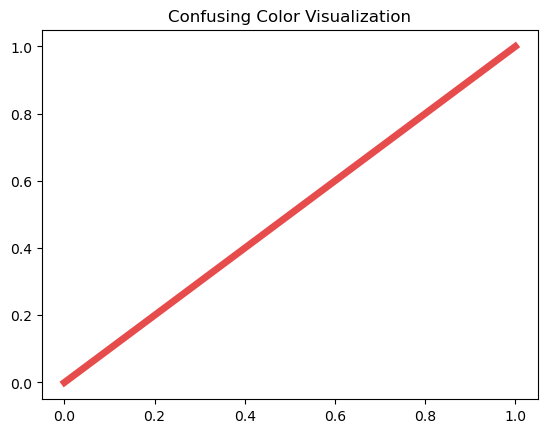

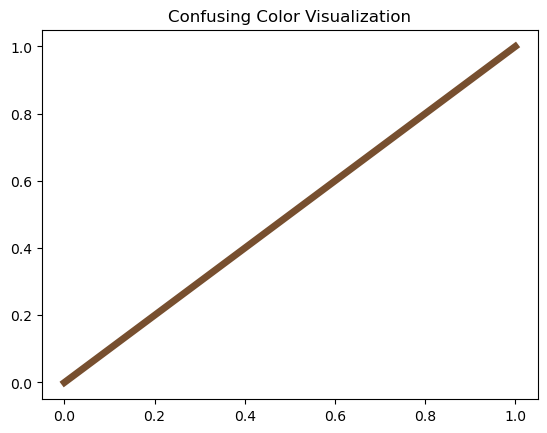

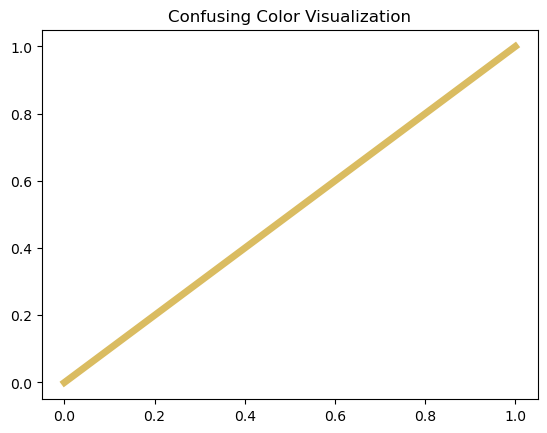

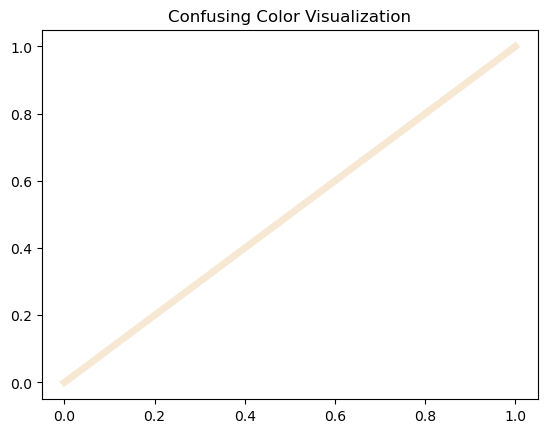

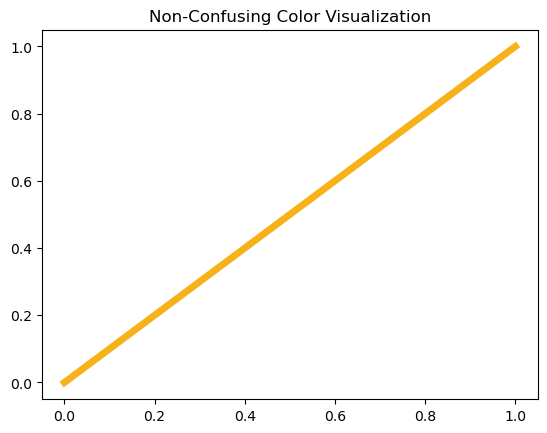

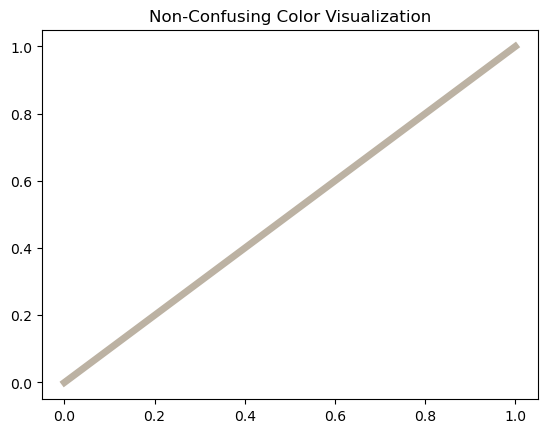

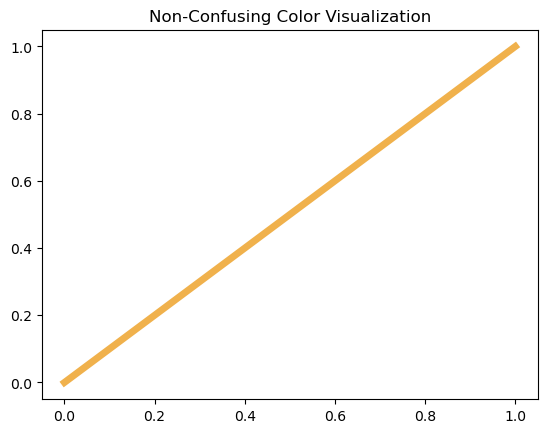

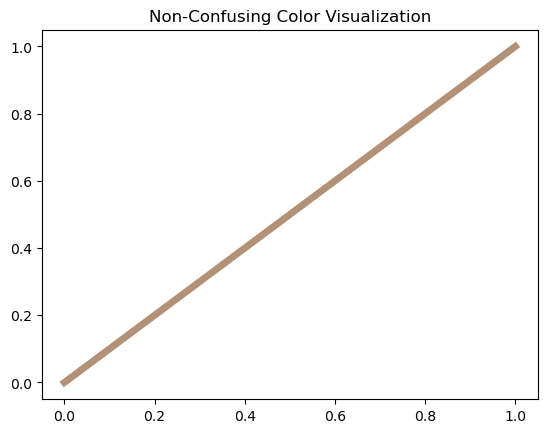

In [99]:
key_c_colors, key_nc_colors = module_1("images/foliage.jpg", 5, 25, deutan, 4, 4)
for c in key_c_colors:
    rgb_color_normalized = (c[0]/255.0, c[1]/255.0, c[2]/255.0)  # Convert 0-255 to 0-1

    plt.plot([0, 1], [0, 1], color=rgb_color_normalized, linewidth=5)
    plt.title("Confusing Color Visualization")
    plt.show()
for c in key_nc_colors:
    rgb_color_normalized = (c[0]/255.0, c[1]/255.0, c[2]/255.0)  # Convert 0-255 to 0-1

    plt.plot([0, 1], [0, 1], color=rgb_color_normalized, linewidth=5)
    plt.title("Non-Confusing Color Visualization")
    plt.show()

In [67]:
rep_colors("images/set_of_tests.jpg", 5)

[(255, 255, 255),
 (234, 231, 226),
 (235, 255, 255),
 (254, 237, 227),
 (255, 255, 231),
 (242, 255, 243),
 (255, 245, 255),
 (237, 248, 255),
 (129, 178, 172),
 (188, 218, 222),
 (231, 216, 184),
 (181, 175, 128),
 (182, 185, 173),
 (129, 124, 76),
 (84, 80, 67),
 (175, 167, 80),
 (236, 175, 131),
 (234, 212, 138),
 (132, 134, 121),
 (232, 186, 172),
 (76, 136, 125),
 (75, 70, 27),
 (30, 28, 14),
 (31, 139, 110),
 (182, 211, 187),
 (171, 158, 41),
 (162, 143, 25),
 (128, 119, 29),
 (124, 74, 31),
 (175, 127, 80),
 (123, 169, 133),
 (12, 79, 26),
 (16, 125, 77),
 (117, 138, 189),
 (80, 164, 129),
 (136, 159, 87),
 (179, 137, 120),
 (144, 216, 214),
 (89, 172, 168),
 (244, 167, 80),
 (123, 85, 68),
 (141, 208, 184),
 (19, 90, 67),
 (172, 189, 220),
 (72, 131, 81),
 (74, 34, 16),
 (95, 74, 118),
 (70, 115, 40),
 (239, 78, 20),
 (235, 126, 77),
 (233, 20, 16),
 (254, 224, 181),
 (254, 186, 173),
 (225, 86, 70),
 (228, 134, 121),
 (255, 84, 64),
 (254, 134, 73),
 (40, 161, 123),
 (255, 12

In [87]:
# takes in image path as string
# renders image under dichromat simulation
def dichromat_simul_img(img_path):
    try:
        img = Image.open(img_path)
        width, height = img.size
        for y in range(height):
            for x in range(width):
                original_rgb = img.getpixel((x, y))
                new_pixel = dichromat_simul(original_rgb, deutan)
                img.putpixel((x, y), (int(new_pixel[0]), int(new_pixel[1]), int(new_pixel[2])))
        img.show()
    except FileNotFoundError:
        print("Image file not found at " + img_path)
    except Exception as e:
        print("An error occurred: " + e)

In [88]:
dichromat_simul_img("images/seven_test.png")

In [ ]:
# Module 2: Key Color Translation
# need to figure out clustering cardinality before doing anything else for module 2

In [ ]:
# List for Phil
'''
 - Explain what we're doing (read through entire paper, implementing modules of paper, implemented colorblindness simulation algorithm)
- Go through this notebook
- Show foliage key color extraction
- Show foliage simulation images, set of tests simulation, and seven simulation (ask about the seven one)
- Goal for midterm report (hopefully midterm 2)
- Pivot towards paper implementation, wrap with some user interface (check about scope)
'''